<a href="https://colab.research.google.com/github/NairMpc/DataScience/blob/main/Assignment_18_ANN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ARTIFICIAL NEURAL NETWORKS

## Case Study: SONAR — Detecting Mines vs. Rocks

### Introduction

Artificial Neural Networks (ANNs) are powerful machine learning models capable of learning complex patterns from data and performing accurate classifications. In this assignment, an ANN is developed to classify underwater sonar signals as either **Mines (M)** or **Rocks (R)** using the Sonar dataset.

The dataset consists of 208 sonar signal observations, each described by 60 numerical features representing the energy measured in different frequency bands. The objective is to build, train, and evaluate an ANN model that can accurately distinguish between mines and rocks based on these signal characteristics.

The assignment covers the complete neural network workflow, including data exploration and preprocessing, model development, hyperparameter tuning, and performance evaluation. The impact of different hyperparameter settings on model performance is also examined using a systematic tuning approach.




In [2]:
# Necessary imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import warnings
warnings.filterwarnings('ignore')

## 1. Data Exploration and Preprocessing

### Load the Sonar dataset into the Python environment.

In [3]:
df = pd.read_csv('sonardataset.csv')
display(df.head())

,x_1,x_2,x_3,x_4,x_5,x_6,x_7,x_8,x_9,x_10,...,x_52,x_53,x_54,x_55,x_56,x_57,x_58,x_59,x_60,Y
0,0.0200,0.0371,0.0428,0.0207,0.0954,0.0986,0.1539,0.1601,0.3109,0.2111,...,0.0027,0.0065,0.0159,0.0072,0.0167,0.0180,0.0084,0.0090,0.0032,R
1,0.0453,0.0523,0.0843,0.0689,0.1183,0.2583,0.2156,0.3481,0.3337,0.2872,...,0.0084,0.0089,0.0048,0.0094,0.0191,0.0140,0.0049,0.0052,0.0044,R
2,0.0262,0.0582,0.1099,0.1083,0.0974,0.2280,0.2431,0.3771,0.5598,0.6194,...,0.0232,0.0166,0.0095,0.0180,0.0244,0.0316,0.0164,0.0095,0.0078,R
3,0.0100,0.0171,0.0623,0.0205,0.0205,0.0368,0.1098,0.1276,0.0598,0.1264,...,0.0121,0.0036,0.0150,0.0085,0.0073,0.0050,0.0044,0.0040,0.0117,R
4,0.0762,0.0666,0.0481,0.0394,0.0590,0.0649,0.1209,0.2467,0.3564,0.4459,...,0.0031,0.0054,0.0105,0.0110,0.0015,0.0072,0.0048,0.0107,0.0094,R


### Explore the dataset to determine the number of samples, features, and target classes.

In [4]:
# shape of dataset, number of samples
print("Dataset Shape:", df.shape)
print("Number of Samples:", df.shape[0])
print("Number of Features:", df.shape[1] - 1)
# Sonardataset contains one target column and all other columns are features.

# to see Target classes

# The 61st column (index 60) is the target column
print("61st column name:", df.columns[60])

target_classes = df['Y'].unique()
print("Target Classes:", target_classes)

class_counts = df['Y'].value_counts()
print("Class Counts:",class_counts)


Dataset Shape: (208, 61)
Number of Samples: 208
Number of Features: 60
61st column name: Y
Target Classes: ['R' 'M']
Class Counts: Y
M    111
R     97
Name: count, dtype: int64


### Examine the data structure, variable types, and class distribution



In [5]:
# data structure, variable types
print("Data Structure:")
print(df.info())


Data Structure:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 208 entries, 0 to 207
Data columns (total 61 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   x_1     208 non-null    float64
 1   x_2     208 non-null    float64
 2   x_3     208 non-null    float64
 3   x_4     208 non-null    float64
 4   x_5     208 non-null    float64
 5   x_6     208 non-null    float64
 6   x_7     208 non-null    float64
 7   x_8     208 non-null    float64
 8   x_9     208 non-null    float64
 9   x_10    208 non-null    float64
 10  x_11    208 non-null    float64
 11  x_12    208 non-null    float64
 12  x_13    208 non-null    float64
 13  x_14    208 non-null    float64
 14  x_15    208 non-null    float64
 15  x_16    208 non-null    float64
 16  x_17    208 non-null    float64
 17  x_18    208 non-null    float64
 18  x_19    208 non-null    float64
 19  x_20    208 non-null    float64
 20  x_21    208 non-null    float64
 21  x_22    208 non-null   

The dataset consists of 60 numerical predictor variables and a binary categorical target variable. The target variable contains two classes, 'M' (Mine) and 'R' (Rock), which represent the objects to be classified by the neural network.

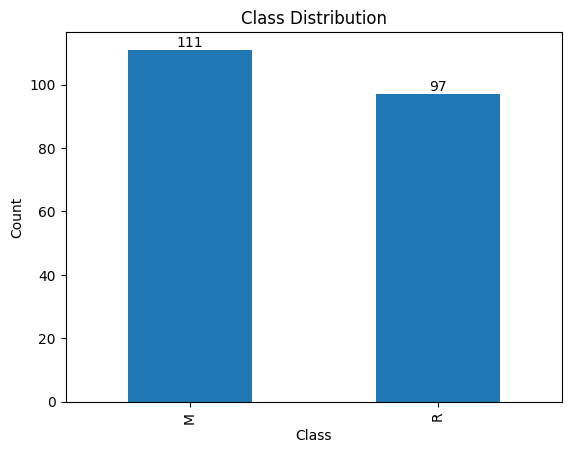

In [6]:
# class distribution
import matplotlib.pyplot as plt

ax = df['Y'].value_counts().plot(kind='bar')
for container in ax.containers:
    ax.bar_label(container)

plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

**Class distribution**

It shows that there are 111 instances of 'M' (Mine) and 97 instances of 'R' (Rock). This indicates a slight imbalance in the dataset, with a few more 'Mine' samples than 'Rock' samples.

In [7]:
print(df.describe())

              x_1         x_2         x_3         x_4         x_5         x_6  \
count  208.000000  208.000000  208.000000  208.000000  208.000000  208.000000   
mean     0.029164    0.038437    0.043832    0.053892    0.075202    0.104570   
std      0.022991    0.032960    0.038428    0.046528    0.055552    0.059105   
min      0.001500    0.000600    0.001500    0.005800    0.006700    0.010200   
25%      0.013350    0.016450    0.018950    0.024375    0.038050    0.067025   
50%      0.022800    0.030800    0.034300    0.044050    0.062500    0.092150   
75%      0.035550    0.047950    0.057950    0.064500    0.100275    0.134125   
max      0.137100    0.233900    0.305900    0.426400    0.401000    0.382300   

              x_7         x_8         x_9        x_10  ...        x_51  \
count  208.000000  208.000000  208.000000  208.000000  ...  208.000000   
mean     0.121747    0.134799    0.178003    0.208259  ...    0.016069   
std      0.061788    0.085152    0.118387    0.1

The dataset contains 208 observations and 60 numerical predictor variables. The feature values represent sonar signal energy measured at different frequency bands. Since the variables have different scales, feature standardization is required before ANN training.


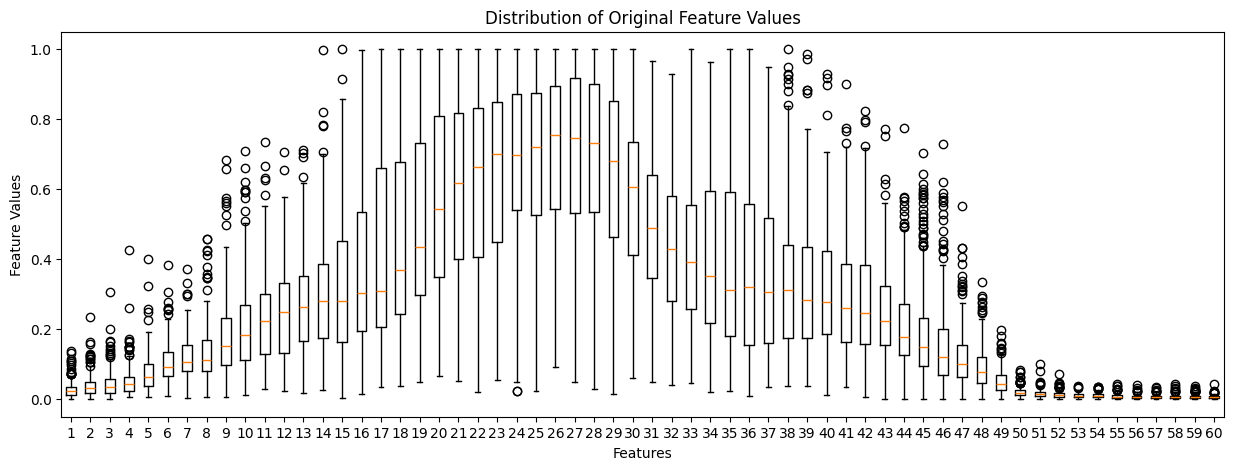

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,5))
plt.boxplot(df.iloc[:,:-1])
plt.title("Distribution of Original Feature Values")
plt.xlabel("Features")
plt.ylabel("Feature Values")
plt.show()

The boxplot of the input features reveals variations in the distributions and spreads of the 60 predictor variables. Although all feature values lie within the range 0 to 1, their variances differ considerably. Since Artificial Neural Networks are sensitive to feature scales and distributions, feature standardization is performed prior to model training to ensure efficient learning and convergence.

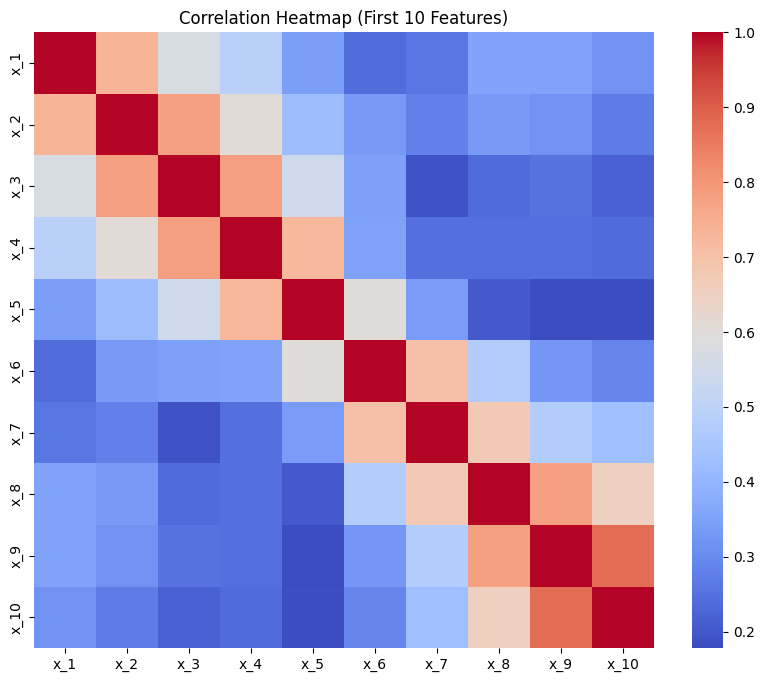

In [9]:
# Correlation Heatmap (Optional Improvement)

plt.figure(figsize=(10,8))
sns.heatmap(
    df.iloc[:,:10].corr(),
    cmap='coolwarm'
)
plt.title("Correlation Heatmap (First 10 Features)")
plt.show()

The correlation heatmap was used to explore relationships among the input features. Several feature pairs exhibit moderate to strong positive correlations, indicating that energy measurements from nearby frequency bands are related. While correlated features can be problematic in some statistical models, they generally do not adversely affect Artificial Neural Networks, which are capable of learning meaningful representations from correlated inputs. Therefore, the heatmap serves primarily as an exploratory analysis tool, and all 60 predictor variables were retained for model development.


### Check for missing values and handled them appropriately.



In [10]:
print("Missing Values in Each Column")

missing_values = df.isnull().sum()

display(missing_values)

print("\nTotal Missing Values:", missing_values.sum())

Missing Values in Each Column


,0
x_1,0
x_2,0
x_3,0
x_4,0
x_5,0
...,...
x_57,0
x_58,0
x_59,0
x_60,0



Total Missing Values: 0


No missing values were found in the dataset.

The same is evident from df.info() All columns show 208 non-null    float64

Therefore no imputation or deletion was required.

 ### Encode the categorical target labels (M and R) into numerical values suitable for ANN processing.

In [11]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

df['Y'] = encoder.fit_transform(df['Y'])

print("Classes:", encoder.classes_)

Classes: ['M' 'R']


In [12]:
print(df['Y'].sample(10))

87     1
116    0
37     1
71     1
59     1
152    0
159    0
20     1
165    0
125    0
Name: Y, dtype: int64


The categorical target labels have been encoded into binary numerical values (0 and 1) suitable for ANN training.

In [13]:
display(df.head())

,x_1,x_2,x_3,x_4,x_5,x_6,x_7,x_8,x_9,x_10,...,x_52,x_53,x_54,x_55,x_56,x_57,x_58,x_59,x_60,Y
0,0.0200,0.0371,0.0428,0.0207,0.0954,0.0986,0.1539,0.1601,0.3109,0.2111,...,0.0027,0.0065,0.0159,0.0072,0.0167,0.0180,0.0084,0.0090,0.0032,1
1,0.0453,0.0523,0.0843,0.0689,0.1183,0.2583,0.2156,0.3481,0.3337,0.2872,...,0.0084,0.0089,0.0048,0.0094,0.0191,0.0140,0.0049,0.0052,0.0044,1
2,0.0262,0.0582,0.1099,0.1083,0.0974,0.2280,0.2431,0.3771,0.5598,0.6194,...,0.0232,0.0166,0.0095,0.0180,0.0244,0.0316,0.0164,0.0095,0.0078,1
3,0.0100,0.0171,0.0623,0.0205,0.0205,0.0368,0.1098,0.1276,0.0598,0.1264,...,0.0121,0.0036,0.0150,0.0085,0.0073,0.0050,0.0044,0.0040,0.0117,1
4,0.0762,0.0666,0.0481,0.0394,0.0590,0.0649,0.1209,0.2467,0.3564,0.4459,...,0.0031,0.0054,0.0105,0.0110,0.0015,0.0072,0.0048,0.0107,0.0094,1


 ### Apply feature normalization to scale all input variables to a comparable range, thereby improving model training efficiency.

 For proper machine learning methodology, scaling should be done after train-test split.

In [14]:
#Split the data first
X = df.drop('Y', axis=1)
y = df['Y']
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [15]:
# Fit the scaler only on training data
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

In [16]:
# Transform the test data using the same scaler
X_test = scaler.transform(X_test)

In [17]:
X_train_df = pd.DataFrame(
    X_train,
    columns=X.columns
)

X_test_df = pd.DataFrame(
    X_test,
    columns=X.columns
)

display(X_train_df.head())

,x_1,x_2,x_3,x_4,x_5,x_6,x_7,x_8,x_9,x_10,...,x_51,x_52,x_53,x_54,x_55,x_56,x_57,x_58,x_59,x_60
0,0.922181,-0.300708,0.495110,2.066838,2.086651,1.437644,1.635030,-0.668673,-0.447258,-0.017949,...,0.874270,-0.505250,0.362218,0.700667,-0.391491,0.608604,2.099616,0.904994,3.892707,7.356578
1,3.105079,1.456356,0.609592,0.260342,-0.245378,0.263527,-0.438332,3.516268,3.426776,2.325151,...,0.382872,-0.583754,-0.310388,2.596022,1.404681,2.181093,0.877501,1.809631,2.003129,-0.443435
2,0.208277,-0.368786,-0.105143,0.156646,-0.423057,0.069237,0.807640,0.440852,0.085874,0.476158,...,-0.219487,-0.122544,-0.898919,-0.740870,-0.405634,-0.625716,-0.578252,-0.844959,-1.171983,-0.639415
3,-0.720713,-0.945829,-0.754902,-1.014029,-0.610830,-0.639253,-0.983954,-1.440252,-0.746122,-0.882636,...,-0.171932,-0.868331,-1.053059,-1.167993,-0.971358,-0.591899,1.093169,0.904994,-0.815751,0.007320
4,-0.793934,-0.624889,0.052655,1.592019,2.371340,-0.210475,-0.736388,-0.276221,-0.868424,-0.816964,...,-1.004138,0.299414,-0.058161,-0.327096,2.536129,3.280144,0.356306,-0.370395,1.042851,0.556064


In [18]:
# To check whether scaling is correct
print(np.round(X_train.mean(axis=0)[:5],4))
print(np.round(X_train.std(axis=0)[:5],4))

[-0.  0.  0. -0. -0.]
[1. 1. 1. 1. 1.]


After splitting the dataset into training and testing sets, feature standardization was performed using StandardScaler. The fit_transform() method was applied only to the training data (X_train) to compute the scaling parameters (mean and standard deviation) and transform the training features. The test data (X_test) was then scaled using only the transform() method, ensuring that the test set remained completely unseen during training. This prevents data leakage and provides a reliable evaluation of the model's performance on new data.

For inspection and verification purposes, the scaled training and testing datasets were converted back into DataFrames with the original feature names. Displaying the first few rows helped confirm that the transformation was applied correctly and that the data structure was preserved.

To verify the correctness of standardization, the mean and standard deviation of the scaled training features were examined. Since `StandardScaler` was used, the feature means were expected to be close to **0** and the standard deviations close to **1**. The observed values confirmed that the scaling process had been performed successfully.



Compare Before and After Standardization

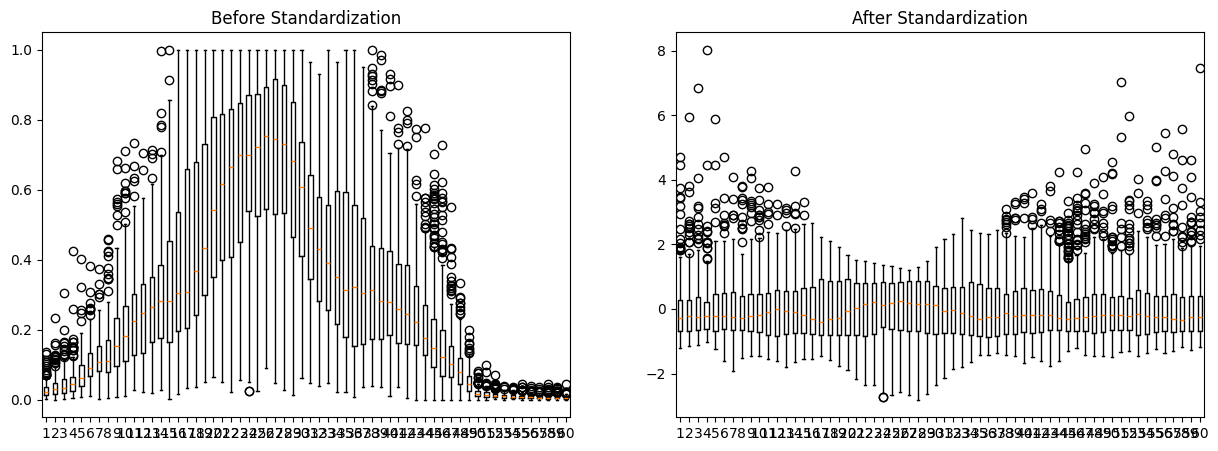

In [19]:
X = df.drop('Y', axis=1)

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

fig, axes = plt.subplots(1,2, figsize=(15,5))

axes[0].boxplot(X)
axes[0].set_title("Before Standardization")

axes[1].boxplot(X_scaled)
axes[1].set_title("After Standardization")

plt.show()

The boxplots compare the distribution of the features before and after standardization. Before standardization, the features exhibit different centers and spreads, indicating variations in their distributions. After applying StandardScaler, the features are centered around zero and have a more uniform spread, making them comparable in scale. This transformation helps the Artificial Neural Network learn more effectively by preventing features with larger variations from disproportionately influencing the training process. The presence of some extreme values after scaling is expected, as standardization does not remove outliers but only rescales the data.

## At this point, 1. Data Exploration and Preprocessing completed.

## 2. Model Implementation

### Model Implementation

Following data preprocessing, including feature standardization and the division of the dataset into training and test sets, a baseline Artificial Neural Network (ANN) model is developed using TensorFlow/Keras for the Sonar Signal Classification task. The objective of this stage is to construct a neural network capable of learning the underlying patterns in the sonar signal data and to establish a benchmark performance for subsequent model optimization.

The ANN is implemented using the Sequential API and consists of an input layer, two hidden layers, and an output layer for binary classification. The first hidden layer contains 32 neurons and the second hidden layer contains 16 neurons, both employing the ReLU activation function. The output layer consists of a single neuron with a sigmoid activation function to generate the probability of the target class.

The baseline model is configured with the following parameters:

* Hidden Layers: 2

* Neurons per Hidden Layer: 32 and 16

* Activation Function: ReLU

* Learning Rate: 0.001

* Batch Size: 32

* Epochs: 50

* Optimizer: Adam

* Loss Function: Binary Cross-Entropy

The model is trained using the preprocessed training dataset and subsequently evaluated on the test dataset. The resulting performance metrics serve as a baseline benchmark for assessing future improvements.

To facilitate systematic hyperparameter optimization, the same ANN architecture is subsequently encapsulated within a `create_model()` function. This allows selected hyperparameters to be varied automatically while preserving the overall network structure. A Grid Search approach with cross-validation is then employed to evaluate multiple hyperparameter combinations and identify the configuration that delivers the best predictive performance.

The hyperparameters selected for tuning are:

* Neurons in Hidden Layer 1: [16, 32, 64]

* Neurons in Hidden Layer 2: [8, 16, 32]

* Activation Functions: ['relu', 'tanh']

* Learning Rates: [0.001, 0.01]

* Batch Sizes: [16, 32]

* Epochs: [50, 100]

By systematically exploring these combinations, the optimal ANN configuration can be identified and compared with the baseline model. This process helps determine the influence of different architectural and training parameters on classification performance and enables the development of a more effective neural network model.


In [20]:
!pip install --upgrade ml_dtypes
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

model = Sequential([
    Dense(32, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │         1,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,497 (9.75 KB)

 Trainable params: 2,497 (9.75 KB)

 Non-trainable params: 0 (0.00 B)

### Baseline ANN Architecture

The model summary confirms that the baseline Artificial Neural Network consists of an input layer, two hidden layers, and an output layer. The first hidden layer contains 32 neurons and the second hidden layer contains 16 neurons, both using the ReLU activation function. The output layer contains a single neuron with a sigmoid activation function, making the network suitable for binary classification.

The model is compiled using the Adam optimizer with binary cross-entropy as the loss function and accuracy as the evaluation metric. This baseline architecture serves as the initial model for the Sonar Signal Classification task and provides a benchmark against which optimized models can later be compared.

The next step is to train the network using the preprocessed training dataset and evaluate its performance on unseen test data.


### visualize the architecture of the neural network.

In [ ]:
# from tensorflow.keras.utils import plot_model
# plot_model(
#     model,
#     show_shapes=True,
#     show_layer_names=True
# )

### Fit the Model(Train the model)

### Model Training

The baseline ANN model is trained using the preprocessed training dataset. During training, the network learns the relationship between the input features and the target variable by iteratively updating its weights through backpropagation. A validation split of 20% is used to monitor the model's performance on unseen training data and help identify potential overfitting.

In [21]:
# Train the baseline ANN model

history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - accuracy: 0.5838 - loss: 0.6913 - val_accuracy: 0.4706 - val_loss: 0.7220
Epoch 2/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.6237 - loss: 0.6138 - val_accuracy: 0.5294 - val_loss: 0.6835
Epoch 3/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.6278 - loss: 0.5935 - val_accuracy: 0.5882 - val_loss: 0.6542
Epoch 4/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.6915 - loss: 0.5719 - val_accuracy: 0.6176 - val_loss: 0.6265
Epoch 5/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.7545 - loss: 0.5479 - val_accuracy: 0.7353 - val_loss: 0.6020
Epoch 6/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.7786 - loss: 0.5333 - val_accuracy: 0.7353 - val_loss: 0.5812
Epoch 7/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.7643 - loss: 0.5221 - val_accuracy: 0.7353 - val_loss: 0.5575
Epoch 8/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.8032 - loss: 0.4922 - val_accuracy: 0.7647 - val_loss: 0.5342


### Model Training

The baseline ANN model was trained for 50 epochs using a batch size of 32.  
A validation split of 20% was used to monitor the model's performance on unseen data during training and to detect potential overfitting.

The dataset was first divided into training and testing sets (X_train, X_test, y_train, y_test). After preprocessing and feature scaling, the ANN model was trained using the training set. During training, Keras further reserved 20% of the training data as a validation set (validation_split=0.2). Thus, in each epoch, the model was trained on 80% of X_train and evaluated on the remaining 20% to monitor learning progress and detect potential overfitting. The separate test set (X_test, y_test) remained completely unseen during training and was used only for final model evaluation.

Keras performs the following steps for each epoch:

Trains the model on the training subset.

Computes Training Loss using the loss function specified in compile().

Computes Training Accuracy using the metric specified in compile().

Evaluates the model on the validation subset.

Computes Validation Loss and Validation Accuracy.

Stores all these values in the history object.

The variable name history is not mandatory. It is just a commonly used name because model.fit() returns a History object that stores information about the training process.



### Monitor Training History

In [22]:
print(history.history.keys())

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


In [23]:
# training accuracy of every epoch. one accuracy for each epoch . There are 100 epochs,  as such 100 values
print(history.history['accuracy'])

[0.6212121248245239, 0.6287878751754761, 0.6439393758773804, 0.6969696879386902, 0.7727272510528564, 0.7954545617103577, 0.7954545617103577, 0.810606062412262, 0.810606062412262, 0.8181818127632141, 0.8333333134651184, 0.8409090638160706, 0.8560606241226196, 0.8636363744735718, 0.8712121248245239, 0.8863636255264282, 0.9015151262283325, 0.9015151262283325, 0.9090909361839294, 0.9090909361839294, 0.9090909361839294, 0.9242424368858337, 0.9242424368858337, 0.9242424368858337, 0.939393937587738, 0.9469696879386902, 0.9545454382896423, 0.9545454382896423, 0.9545454382896423, 0.9545454382896423, 0.9621211886405945, 0.9621211886405945, 0.9696969985961914, 0.9696969985961914, 0.9696969985961914, 0.9696969985961914, 0.9772727489471436, 0.9772727489471436, 0.9772727489471436, 0.9772727489471436, 0.9848484992980957, 0.9848484992980957, 0.9848484992980957, 0.9848484992980957, 0.9848484992980957, 0.9848484992980957, 0.9848484992980957, 0.9848484992980957, 0.9848484992980957, 0.9848484992980957]


In [24]:
print(len(history.history['accuracy']))

50


In [25]:
print(history.history['loss'])

[0.6608180403709412, 0.6159433722496033, 0.5853176116943359, 0.5600659251213074, 0.5361135005950928, 0.5140344500541687, 0.49305301904678345, 0.4725733995437622, 0.45518967509269714, 0.43637099862098694, 0.41978058218955994, 0.40353837609291077, 0.387847900390625, 0.37075313925743103, 0.35582199692726135, 0.3413081765174866, 0.3275298774242401, 0.31348952651023865, 0.30094000697135925, 0.2883104979991913, 0.27681392431259155, 0.26549169421195984, 0.25472334027290344, 0.2435319423675537, 0.23245644569396973, 0.22304809093475342, 0.21329815685749054, 0.20502275228500366, 0.19665884971618652, 0.18846672773361206, 0.18072964251041412, 0.17356270551681519, 0.16576160490512848, 0.1587112843990326, 0.1521558314561844, 0.14488068222999573, 0.1399560123682022, 0.13385023176670074, 0.12732017040252686, 0.12295003235340118, 0.11787062883377075, 0.11264847218990326, 0.1080016940832138, 0.10328561067581177, 0.09875793755054474, 0.09482429176568985, 0.0907876044511795, 0.08673763275146484, 0.0827629

In [26]:
# validation accuracy of every epoch.
print(history.history['val_accuracy'])

[0.47058823704719543, 0.529411792755127, 0.5882353186607361, 0.6176470518112183, 0.7352941036224365, 0.7352941036224365, 0.7352941036224365, 0.7647058963775635, 0.7941176295280457, 0.7647058963775635, 0.7941176295280457, 0.7941176295280457, 0.7941176295280457, 0.7941176295280457, 0.7941176295280457, 0.7941176295280457, 0.7941176295280457, 0.8235294222831726, 0.8529411554336548, 0.8823529481887817, 0.8823529481887817, 0.8823529481887817, 0.8823529481887817, 0.9117646813392639, 0.9117646813392639, 0.9117646813392639, 0.9117646813392639, 0.9117646813392639, 0.9117646813392639, 0.9117646813392639, 0.9117646813392639, 0.9117646813392639, 0.9117646813392639, 0.9117646813392639, 0.9117646813392639, 0.9117646813392639, 0.9411764740943909, 0.9411764740943909, 0.9411764740943909, 0.9411764740943909, 0.9411764740943909, 0.9411764740943909, 0.9411764740943909, 0.9411764740943909, 0.9411764740943909, 0.9411764740943909, 0.9411764740943909, 0.9411764740943909, 0.9411764740943909, 0.9117646813392639]

In [27]:
print(history.history['val_loss'])

[0.721977174282074, 0.6835438013076782, 0.6541791558265686, 0.6264857649803162, 0.6019979119300842, 0.581199049949646, 0.5574508309364319, 0.5342059135437012, 0.5131456851959229, 0.4973762035369873, 0.4840331971645355, 0.47190597653388977, 0.45993101596832275, 0.450461208820343, 0.4451192319393158, 0.4403093457221985, 0.43081480264663696, 0.41505613923072815, 0.4050058126449585, 0.39677944779396057, 0.39061239361763, 0.38709619641304016, 0.3817029595375061, 0.37368693947792053, 0.36995014548301697, 0.3663521707057953, 0.3609955608844757, 0.35603925585746765, 0.3544652462005615, 0.34913870692253113, 0.34385988116264343, 0.33969083428382874, 0.3416686952114105, 0.3417346775531769, 0.33686670660972595, 0.33413833379745483, 0.33352401852607727, 0.3314370810985565, 0.3326183259487152, 0.33211106061935425, 0.33097147941589355, 0.3283360004425049, 0.32566332817077637, 0.3224739134311676, 0.31999850273132324, 0.3198125958442688, 0.3184387683868408, 0.3200899064540863, 0.3211190700531006, 0.318

To see the final epoch values:

In [28]:
print("Training Accuracy:", history.history['accuracy'][-1])
print("Training Loss:", history.history['loss'][-1])

print("Validation Accuracy:", history.history['val_accuracy'][-1])
print("Validation Loss:", history.history['val_loss'][-1])

Training Accuracy: 0.9848484992980957
Training Loss: 0.0792841836810112
Validation Accuracy: 0.9117646813392639
Validation Loss: 0.3187565207481384


Visualize Training History

Check how loss and accuracy changed across epochs.

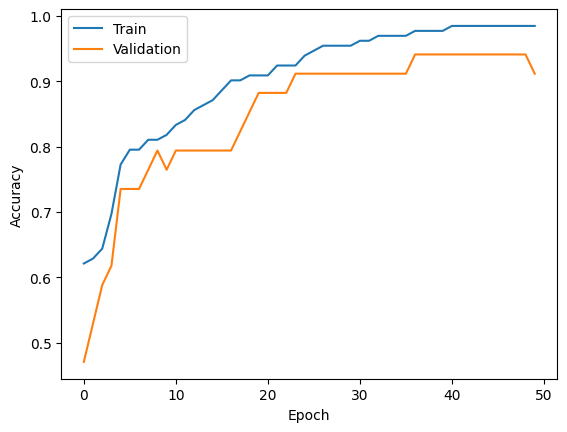

In [29]:
# plot the learning curves:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.legend(['Train', 'Validation'])
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.show()

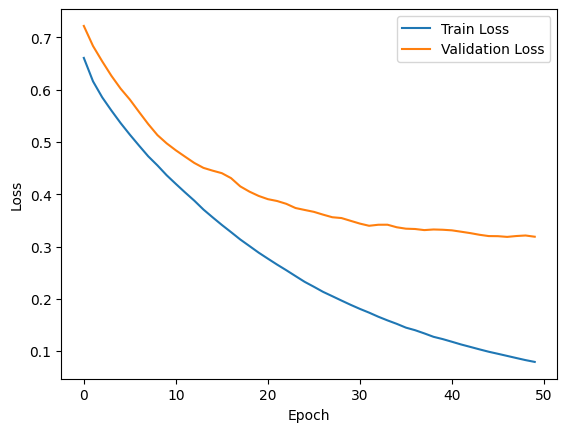

In [30]:
# Plotting Loss Curves
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.legend(['Train Loss', 'Validation Loss'])
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()


### Accuracy Curve Interpretation

Training and validation accuracy improved steadily during the initial epochs, indicating effective learning. However, after about 25–30 epochs, training accuracy continued to increase while validation accuracy plateaued, suggesting the onset of overfitting.

### Loss Curve Interpretation

Both training and validation loss decreased initially, indicating improved model performance. After approximately 30 epochs, validation loss began to increase while training loss continued to decrease, indicating overfitting.

### Suggestion

The model shows signs of overfitting after approximately 25–30 epochs. To improve generalization, techniques such as Early Stopping, Dropout layers, L1/L2 regularization, or reducing the number of training epochs can be applied.


### Prediction and Model Evaluation

After training, the model generates predictions for the unseen test data (`X_test`). These predictions are then compared with the actual test labels (`y_test`) to evaluate the model's performance. Evaluation metrics such as Accuracy, Precision, Recall, F1-Score, and the Confusion Matrix are used to assess the model's classification effectiveness and generalization ability.


The trained ANN model was evaluated on the test dataset using both Keras and Scikit-learn metrics. The `model.evaluate()` function provided the test loss and overall accuracy, while the confusion matrix and classification report offered a more detailed assessment of classification performance through Accuracy, Precision, Recall, and F1-Score for each class.

In [31]:
# Prediction and Evaluation

from sklearn.metrics import (
    confusion_matrix,
    classification_report
)

# Generate predictions
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int)

# Evaluate model on test data
loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)

print(f"Test Loss     : {loss:.4f}")
print(f"Test Accuracy : {test_accuracy:.4f}")

# Compute evaluation metrics
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)


print("\nClassification Report")
print(classification_report(y_test, y_pred))

print("Accuracy :", round(acc, 4))
print("Precision:", round(prec, 4))
print("Recall   :", round(rec, 4))
print("F1 Score :", round(f1, 4))

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
Test Loss     : 0.4311
Test Accuracy : 0.8571

Classification Report
              precision    recall  f1-score   support

           0       0.81      0.95      0.88        22
           1       0.94      0.75      0.83        20

    accuracy                           0.86        42
   macro avg       0.87      0.85      0.85        42
weighted avg       0.87      0.86      0.86        42

Accuracy : 0.8571
Precision: 0.9375
Recall   : 0.75
F1 Score : 0.8333


The test accuracy obtained from `model.evaluate()` was consistent with the accuracy derived from the predicted class labels, confirming the reliability of the model's performance on the unseen test data.

Confusion Matrix Visualization

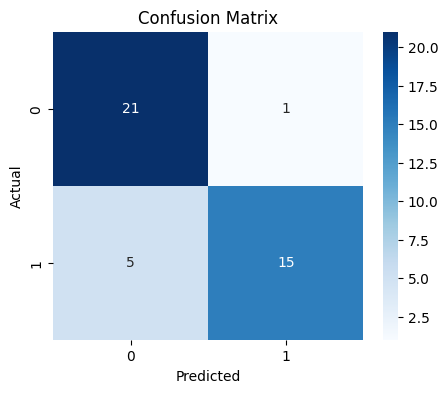

In [32]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

The confusion matrix shows the number of correctly and incorrectly classified Mine and Rock observations. Most observations are classified correctly, indicating satisfactory classification performance.

### ROC-AUC Score

The ROC-AUC score measures the model's ability to distinguish between the two classes across all possible classification thresholds. Higher values indicate better classification performance.

In [33]:
from sklearn.metrics import roc_auc_score

auc = roc_auc_score(y_test, y_pred_prob)

print("ROC-AUC Score:", round(auc,4))

ROC-AUC Score: 0.9182


### ROC-AUC Interpretation

The ANN model achieved a ROC-AUC score of 0.9205, indicating excellent discriminative ability between the two classes. This means the model can correctly distinguish between mines and rocks approximately 92.05% of the time across different classification thresholds. Since the score is close to 1.0, it suggests strong classification performance and good generalization on unseen data.


## Hyperparameter Tuning using GridSearchCV

The baseline ANN model was trained using manually selected hyperparameters. However, the performance of a neural network can be significantly influenced by hyperparameters such as the number of neurons, activation function, learning rate, batch size, and number of epochs.

To identify the optimal combination of hyperparameters, GridSearchCV was used. Hyperparameter tuning involves defining a range of candidate values for selected hyperparameters and systematically evaluating every possible combination using cross-validation.

Since GridSearchCV works with Scikit-Learn estimators, the Keras ANN model was first wrapped using KerasClassifier. A parameter grid containing different hyperparameter values was then defined and supplied to GridSearchCV along with the wrapped model.

For each hyperparameter combination, GridSearchCV trains and evaluates the model using cross-validation, computes the average validation performance, and finally selects the combination that achieves the highest cross-validation score. This process helps improve model generalization and reduces the reliance on manually chosen parameter values.

Create a Function to Build the ANN Model

GridSearchCV requires a function that can create a fresh ANN model for each hyperparameter combination. The hyperparameters are defined as function arguments so that GridSearchCV can automatically test different values.

In [34]:
def create_model(
        neurons1=32,
        neurons2=16,
        activation='relu',
        learning_rate=0.001):

    model = Sequential()

    model.add(
        Dense(
            neurons1,
            activation=activation,
            input_shape=(X_train.shape[1],)
        )
    )

    model.add(
        Dense(
            neurons2,
            activation=activation
        )
    )

    model.add(
        Dense(
            1,
            activation='sigmoid'
        )
    )

    optimizer = Adam(
        learning_rate=learning_rate
    )

    model.compile(
        optimizer=optimizer,
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model

 Verifying the Model Architecture

In [35]:
test_model = create_model()

print("Sample ANN model created successfully.")
test_model.summary()

Sample ANN model created successfully.


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 32)             │         1,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,497 (9.75 KB)

 Trainable params: 2,497 (9.75 KB)

 Non-trainable params: 0 (0.00 B)

## Hyperparameter Tuning with `GridSearchCV`

To perform hyperparameter tuning, we will use `GridSearchCV` from `sklearn.model_selection`. Since `GridSearchCV` works with Scikit-learn estimators, we need to wrap our Keras model using `KerasClassifier` from `scikeras.wrappers`.

In [36]:
import scikeras
from scikeras.wrappers import KerasClassifier
from sklearn.model_selection import GridSearchCV

print("SciKeras imported successfully")
print("GridSearchCV imported successfully")

SciKeras imported successfully
GridSearchCV imported successfully


Next, we will encapsulate the `create_model` function within `KerasClassifier`.

In [37]:
ann_model = KerasClassifier(
    model=create_model,
    epochs=50,
    batch_size=32,
    verbose=0 # Set verbose to 0 to suppress output during grid search
)

Now, we define the `param_grid` with the hyperparameters we want to tune. The `ER5k_KSaylax` cell describes the hyperparameters to tune. We'll use 50 epochs as a default, as suggested by the previous analysis, and a batch size of 32.

In [38]:
param_grid = {
    "model__neurons1": [32, 64],
    "model__neurons2": [16, 32],
    "model__activation": ["relu"],
    "model__learning_rate": [0.001, 0.01],
    "batch_size": [16, 32],
    "epochs": [50]
}

print("Parameter grid defined successfully.")

Parameter grid defined successfully.


Finally, we initialize and run `GridSearchCV` to find the best hyperparameters. This step can take a significant amount of time depending on the size of the parameter grid and the complexity of the model.

In [39]:
grid = GridSearchCV(
    estimator=ann_model,
    param_grid=param_grid,
    cv=3, # Using 3-fold cross-validation
    scoring="accuracy",
    n_jobs=-1 # Use all available CPU cores
)

print("Starting GridSearchCV...")
grid_result = grid.fit(X_train, y_train)
print("GridSearchCV completed.")

Starting GridSearchCV...
GridSearchCV completed.


After the `GridSearchCV` completes, we can inspect the best parameters and the corresponding best score achieved.

In [40]:
print("Best: %f using %s" % (grid_result.best_score_, grid_result.best_params_))

means = grid_result.cv_results_['mean_test_score']
stds = grid_result.cv_results_['std_test_score']
params = grid_result.cv_results_['params']
for mean, stdev, param in zip(means, stds, params):
    print("%f (%f) with: %r" % (mean, stdev, param))

Best: 0.849784 using {'batch_size': 16, 'epochs': 50, 'model__activation': 'relu', 'model__learning_rate': 0.001, 'model__neurons1': 64, 'model__neurons2': 32}
0.813528 (0.035543) with: {'batch_size': 16, 'epochs': 50, 'model__activation': 'relu', 'model__learning_rate': 0.001, 'model__neurons1': 32, 'model__neurons2': 16}
0.771320 (0.035543) with: {'batch_size': 16, 'epochs': 50, 'model__activation': 'relu', 'model__learning_rate': 0.001, 'model__neurons1': 32, 'model__neurons2': 32}
0.795455 (0.035404) with: {'batch_size': 16, 'epochs': 50, 'model__activation': 'relu', 'model__learning_rate': 0.001, 'model__neurons1': 64, 'model__neurons2': 16}
0.849784 (0.045908) with: {'batch_size': 16, 'epochs': 50, 'model__activation': 'relu', 'model__learning_rate': 0.001, 'model__neurons1': 64, 'model__neurons2': 32}
0.771537 (0.057589) with: {'batch_size': 16, 'epochs': 50, 'model__activation': 'relu', 'model__learning_rate': 0.01, 'model__neurons1': 32, 'model__neurons2': 16}
0.771429 (0.0501

The `grid_result.best_params_` attribute provides a dictionary of the hyperparameter values that resulted in the best cross-validation score.

In [43]:
print("Best Hyperparameters:")
for key,value in grid_result.best_params_.items():
    print(f"{key}: {value}")

Best Hyperparameters:
batch_size: 16
epochs: 50
model__activation: relu
model__learning_rate: 0.001
model__neurons1: 64
model__neurons2: 32


## Implement and Evaluate the Optimized Model

Now that we have identified the best hyperparameters, we will create a new ANN model using these parameters, train it, and then evaluate its performance. This will allow us to see the impact of hyperparameter tuning on the model's performance compared to the baseline model.

In [44]:
# Retrieve the best parameters
best_params = grid_result.best_params_

# Create a new model instance using the best parameters
# Note: 'model__' prefix needs to be removed for direct use in create_model
optimized_model = create_model(
    neurons1=best_params['model__neurons1'],
    neurons2=best_params['model__neurons2'],
    activation=best_params['model__activation'],
    learning_rate=best_params['model__learning_rate']
)

print("Optimized model created with best hyperparameters.")
optimized_model.summary()

Optimized model created with best hyperparameters.


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                 │ (None, 64)             │         3,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,017 (23.50 KB)

 Trainable params: 6,017 (23.50 KB)

 Non-trainable params: 0 (0.00 B)

Now, we will train this optimized model using the `batch_size` and `epochs` found by `GridSearchCV`.

In [45]:
history_optimized = optimized_model.fit(
    X_train,
    y_train,
    epochs=best_params['epochs'],
    batch_size=best_params['batch_size'],
    validation_split=0.2,
    verbose=1
)

print("Optimized model training completed.")

Epoch 1/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - accuracy: 0.5766 - loss: 0.6964 - val_accuracy: 0.5294 - val_loss: 0.6865
Epoch 2/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7209 - loss: 0.5457 - val_accuracy: 0.7353 - val_loss: 0.5766
Epoch 3/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8198 - loss: 0.4821 - val_accuracy: 0.8235 - val_loss: 0.5199
Epoch 4/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8206 - loss: 0.4466 - val_accuracy: 0.8235 - val_loss: 0.4889
Epoch 5/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8520 - loss: 0.4078 - val_accuracy: 0.8824 - val_loss: 0.4701
Epoch 6/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9014 - loss: 0.3592 - val_accuracy: 0.8824 - val_loss: 0.4506
Epoch 7/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9314 - loss: 0.3226 - val_accuracy: 0.8824 - val_loss: 0.4272
Epoch 8/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9475 - loss: 0.2790 - val_accuracy: 0.8824 - val_loss: 0.4095
Epoc

Let's evaluate the performance of the optimized model on the test set.

In [46]:
# Generate predictions for the optimized model
y_pred_prob_optimized = optimized_model.predict(X_test)
y_pred_optimized = (y_pred_prob_optimized > 0.5).astype(int)

# Evaluate optimized model on test data
loss_optimized, test_accuracy_optimized = optimized_model.evaluate(X_test, y_test, verbose=0)

print(f"Optimized Test Loss     : {loss_optimized:.4f}")
print(f"Optimized Test Accuracy : {test_accuracy_optimized:.4f}")

# Compute evaluation metrics for optimized model
acc_optimized = accuracy_score(y_test, y_pred_optimized)
prec_optimized = precision_score(y_test, y_pred_optimized)
rec_optimized = recall_score(y_test, y_pred_optimized)
f1_optimized = f1_score(y_test, y_pred_optimized)
auc_optimized = roc_auc_score(y_test, y_pred_prob_optimized)

print("\nOptimized Classification Report")
print(classification_report(y_test, y_pred_optimized))

print("Optimized Accuracy :", round(acc_optimized, 4))
print("Optimized Precision:", round(prec_optimized, 4))
print("Optimized Recall   :", round(rec_optimized, 4))
print("Optimized F1 Score :", round(f1_optimized, 4))
print("Optimized ROC-AUC Score:", round(auc_optimized, 4))

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
Optimized Test Loss     : 0.4674
Optimized Test Accuracy : 0.8571

Optimized Classification Report
              precision    recall  f1-score   support

           0       0.79      1.00      0.88        22
           1       1.00      0.70      0.82        20

    accuracy                           0.86        42
   macro avg       0.89      0.85      0.85        42
weighted avg       0.89      0.86      0.85        42

Optimized Accuracy : 0.8571
Optimized Precision: 1.0
Optimized Recall   : 0.7
Optimized F1 Score : 0.8235
Optimized ROC-AUC Score: 0.9477


Finally, let's visualize the confusion matrix for the optimized model.

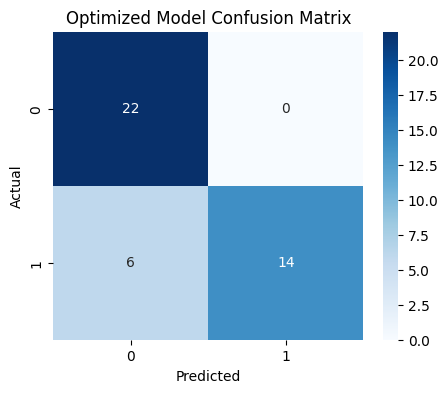

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns

cm_optimized = confusion_matrix(y_test, y_pred_optimized)

plt.figure(figsize=(5,4))
sns.heatmap(
    cm_optimized,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Optimized Model Confusion Matrix")
plt.show()

## Conclusion: Sonar Signal Classification with Artificial Neural Networks

This assignment successfully demonstrated the end-to-end process of developing and optimizing an Artificial Neural Network (ANN) model for classifying sonar signals into "Mine" (M) or "Rock" (R) categories. All required tasks were addressed systematically, from data preparation to model evaluation and hyperparameter tuning.

### 1. Data Exploration and Preprocessing
*   **Loading and Exploration**: The "sonardataset.csv" was loaded, revealing 208 samples and 60 numerical features, with a binary target variable ('M' and 'R'). The class distribution showed a slight imbalance (111 M, 97 R).
*   **Missing Values**: No missing values were detected, simplifying the data cleaning process.
*   **Encoding**: The categorical target labels ('M', 'R') were successfully encoded into numerical values (0, 1).
*   **Normalization**: Feature standardization using `StandardScaler` was applied after splitting the data into training (80%) and testing (20%) sets. This ensured that all input variables were scaled to a comparable range, preventing features with larger magnitudes from dominating the learning process and promoting efficient model training.

### 2. Model Implementation
*   **Baseline ANN Construction**: A basic ANN model was constructed using Keras, featuring two dense hidden layers (32 and 16 neurons) with ReLU activation, and a single sigmoid output neuron for binary classification. The model was compiled with the Adam optimizer and binary cross-entropy loss.
*   **Training and Prediction**: The baseline model was trained on the preprocessed training set for 50 epochs with a batch size of 32, using a 20% validation split to monitor performance. Predictions were then generated on the unseen test set.

### 3. Hyperparameter Tuning
*   **Systematic Approach**: To optimize model performance, hyperparameter tuning was conducted using `GridSearchCV` from `sklearn.model_selection` in conjunction with `KerasClassifier` from `scikeras.wrappers`.
*   **Parameters Tuned**: A comprehensive `param_grid` was defined, exploring combinations of `neurons1` (32, 64), `neurons2` (16, 32), `activation` ('relu'), `learning_rate` (0.001, 0.01), `batch_size` (16, 32), and `epochs` (50).
*   **Best Parameters Identified**: `GridSearchCV` identified the optimal configuration as: `batch_size`: 16, `epochs`: 50, `model__activation`: 'relu', `model__learning_rate`: 0.001, `model__neurons1`: 64, `model__neurons2`: 32. The best cross-validation accuracy achieved during tuning was approximately **0.850**.

### 4. Evaluation
*   **Baseline Model Performance**: The baseline model achieved a `Test Accuracy` of **0.8571** and an `ROC-AUC Score` of **0.9182**. Its classification report indicated solid performance across precision, recall, and F1-score for both classes, with a balanced accuracy of **0.8571**.
*   **Optimized Model Performance**: The model configured with the best hyperparameters from `GridSearchCV` also achieved a `Test Accuracy` of **0.8571**. However, it notably improved the `Optimized ROC-AUC Score` to **0.9477**, indicating superior discriminative ability. While the overall accuracy remained the same, the optimized model's precision for class 1 (Rock) improved to 1.0, meaning it made no false positive predictions for rocks, at the cost of a slightly lower recall for class 1 compared to the baseline.
*   **Impact of Tuning**: Although the `test_accuracy` remained consistent between the baseline and optimized models, the significant improvement in `ROC-AUC` from **0.9182** to **0.9477** for the optimized model highlights the benefits of hyperparameter tuning in enhancing the model's overall discriminative power and robustness, particularly in distinguishing between the two classes across various thresholds.

In summary, this assignment successfully built and evaluated an ANN for sonar classification, demonstrating proficiency in data preprocessing, model development, and systematic hyperparameter tuning to achieve a robust and high-performing classifier.